In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbesg import SmithWilson, DynamicNelsonSiegel

In [2]:
# 환경설정
os.makedirs('img', exist_ok=True)
os.makedirs('result', exist_ok=True)
plt.style.use('seaborn')

In [8]:
# settings (volatility adjustment, interpolation/extrapolation, rounding, etc)
va = 0.40
maturity = np.array([0.25, 0.5, 0.75, 1., 1.5, 2., 2.5, 3., 5., 7., 10., 15., 20.])
base_rf = np.array([1.52, 1.63, 1.78, 1.88, 2.01, 2.09, 2.15, 2.16, 2.36, 2.45, 2.48, 2.47, 2.47])
terminal = 60
ufr_liab = 5.2
rounded = 3
months = np.linspace(0, 100, 100*12+1)
sw_liab = SmithWilson(ufr=np.log(1+ufr_liab/100), terminal=terminal)
sw_liab.train(maturity, (base_rf+va)/100)

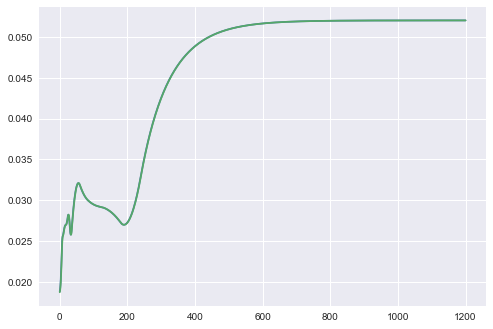

In [17]:
plt.plot(sw_liab.forward1M(months));
plt.plot(sw_liab.forward(months));

In [8]:
# result
stochastic_asset_spot = []
stochastic_liab_spot = []
stochastic_asset_forward = []
stochastic_liab_forward = []
for i in range(num_scen):
    base_rf_var = base_rf+stochastic_scenario[i]
    sw_asset.train(maturity, base_rf_var/100)
    sw_liab.train(maturity, (base_rf_var+va)/100)
    stochastic_asset_spot.append(np.round(sw_asset.spot(months)*100,rounded))
    stochastic_liab_spot.append(np.round(sw_liab.spot(months)*100,rounded))
    stochastic_asset_forward.append(np.round(sw_asset.forward1M(months)*100,rounded))
    stochastic_liab_forward.append(np.round(sw_liab.forward1M(months)*100,rounded))
stochastic_asset_spot = np.r_[stochastic_asset_spot]
stochastic_liab_spot = np.r_[stochastic_liab_spot]
stochastic_asset_forward = np.r_[stochastic_asset_forward]
stochastic_liab_forward = np.r_[stochastic_liab_forward]
    
shock_asset_spot = []
shock_liab_spot = []
shock_asset_forward = []
shock_liab_forward = []
# 2021.03.08 수정
for i in range(6):
    base_rf_var = base_rf+shock_scenario[i]
    sw_asset.train(maturity, base_rf_var/100)
    sw_liab_appl = sw_liab_up if i==2 else sw_liab_down if i==3 else sw_liab
    sw_liab_appl.train(maturity, (base_rf_var+va)/100)
    shock_asset_spot.append(np.round(sw_asset.spot(months)*100,rounded))
    shock_liab_spot.append(np.round(sw_liab_appl.spot(months)*100,rounded))
    shock_asset_forward.append(np.round(sw_asset.forward1M(months)*100,rounded))
    shock_liab_forward.append(np.round(sw_liab_appl.forward1M(months)*100,rounded))
shock_asset_spot = np.r_[shock_asset_spot]
shock_liab_spot = np.r_[shock_liab_spot]
shock_asset_forward = np.r_[shock_asset_forward]
shock_liab_forward = np.r_[shock_liab_forward]

In [9]:
# to excel
col_spot = [f"{i:04d}M" for i in range(0, 1201)]
col_forward = [f"{i:04d}M" for i in range(1, 1202)]
df_stochastic_asset_spot = pd.DataFrame(stochastic_asset_spot, index=np.arange(1, num_scen+1), columns=col_spot)
df_shock_asset_spot = pd.DataFrame(shock_asset_spot, index=shock_name, columns=col_spot)
df_stochastic_asset_forward = pd.DataFrame(stochastic_asset_forward, index=np.arange(1, num_scen+1), columns=col_forward)
df_shock_asset_forward = pd.DataFrame(shock_asset_forward, index=shock_name, columns=col_forward)
df_stochastic_liab_spot = pd.DataFrame(stochastic_liab_spot, index=np.arange(1, num_scen+1), columns=col_spot)
df_shock_liab_spot = pd.DataFrame(shock_liab_spot, index=shock_name, columns=col_spot)
df_stochastic_liab_forward = pd.DataFrame(stochastic_liab_forward, index=np.arange(1, num_scen+1), columns=col_forward)
df_shock_liab_forward = pd.DataFrame(shock_liab_forward, index=shock_name, columns=col_forward)

now = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
if not any([s == 'result' for s in os.listdir('.')]):
    os.mkdir('result')
with pd.ExcelWriter(f'result/dns_model_scenarios_{now}.xlsx', 'xlsxwriter') as writer:
    df_stochastic_asset_spot.to_excel(writer, 'stochastic_asset_spot')
    df_shock_asset_spot.to_excel(writer, 'shock_asset_spot')
    df_stochastic_asset_forward.to_excel(writer, 'stochastic_asset_forward')
    df_shock_asset_forward.to_excel(writer, 'shock_asset_forward')
    df_stochastic_liab_spot.to_excel(writer, 'stochastic_liab_spot')
    df_shock_liab_spot.to_excel(writer, 'shock_liab_spot')
    df_stochastic_liab_forward.to_excel(writer, 'stochastic_liab_forward')
    df_shock_liab_forward.to_excel(writer, 'shock_liab_forward')